In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D, MaxPooling2D , Flatten
import matplotlib.pyplot as plt


# data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# using image_dataset_directory because it will load the data in chunks into the memory instead of loading all the data into the RAM
# so to save computing resources and RAM i have used this function

dataset_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals"
train_data= tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=42,
    labels="inferred",
    label_mode = "binary",
    validation_split=0.2,
    subset="training",
    image_size=(256,256),
    batch_size=32
)
val_data= tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=42,
    labels="inferred",
    label_mode="binary",
    image_size=(256,256),
    subset="validation",
    validation_split=0.2,
    batch_size=32
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


2026-07-27 19:21:03.197743: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [3]:
#Normalizing the dataset because all values are in the range 1 to 255 because we  have used numpy

def process(image,label):
    image= tf.cast(image/255.,tf.float32)
    return image,label

validation_dataset = val_data.map(process)
train_dataset= val_data.map(process)

In [4]:
# Building the CNN architecture 


model = Sequential()

# Adding Convolutional Layers 

model.add(Conv2D(32,kernel_size=(3,3), padding ="valid", activation="relu",input_shape=(256,256,3)))


model.add(MaxPooling2D(pool_size=(2,2),strides=2 , padding="valid"))


model.add(Conv2D(64,kernel_size=(3,3), padding ="valid", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2 , padding="valid"))

model.add(Conv2D(128,kernel_size=(3,3), padding ="valid", activation="relu",))
model.add(MaxPooling2D(pool_size=(2,2),strides=2 , padding="valid"))


# Flattening the output map feature to a single list 

model.add(Flatten())

# Now adding the connected layer


model.add(Dense(128,activation="relu"))

model.add(Dense(64,activation="relu"))

model.add(Dense(1,activation= "sigmoid"))


model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [6]:
history=model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5150 - loss: 0.9449 - val_accuracy: 0.4950 - val_loss: 0.6885
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.6100 - loss: 0.6771 - val_accuracy: 0.5650 - val_loss: 0.6282
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6200 - loss: 0.6430 - val_accuracy: 0.6150 - val_loss: 0.5940
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7700 - loss: 0.5912 - val_accuracy: 0.7600 - val_loss: 0.4858
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7700 - loss: 0.4841 - val_accuracy: 0.8450 - val_loss: 0.4057
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8800 - loss: 0.3880 - val_accuracy: 0.8250 - val_loss: 0.3366
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.8750 - loss: 0.2815 - val_accuracy: 0.8900 - val_loss: 0.2808
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9100 - loss: 0.2423 - val_accuracy: 0.9150 - val_loss: 0.2107
Epoch 9/

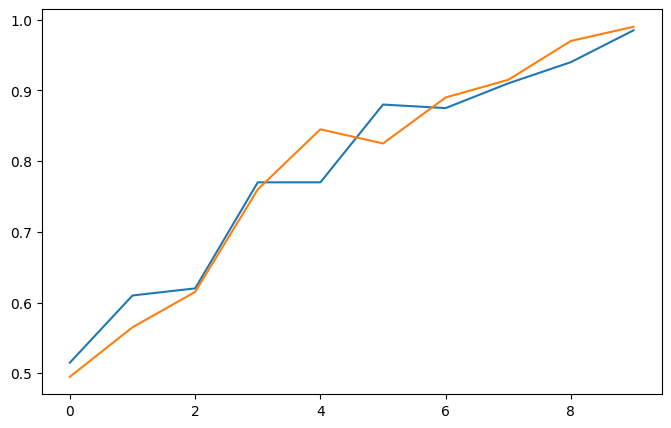

In [7]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()